# Quickstart Notebook

This notebook loads a CSV dataset using the shared dataloader utilities.

## Setup and load data
Add the project root to the import path, load the TXT dataset, and split into train/test for modeling.

In [35]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for imports
project_root = Path("../..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_txt, preprocess, GWASDataset

type = "SCZ"
clumping = "0.0001"

data_path = Path(f"../../data/tmpDATA-Leon/donnees_MRI_{type}_only_variants_clumping_p_thr_{clumping}all.txt")

df = load_txt(data_path)
X_train, y_train, X_test, y_test = preprocess(df=df, target=f"Z_scores_{type}", testsize = 0.2)


## Train RRFS and rank features
Run the teacher/student training across seeds, collect feature importances, and plot losses.

Training Teacher (Autoencoder)...
Epoch 1/200, Loss: 200.1141, Test Loss: 197.8534
Epoch 5/200, Loss: 143.1660, Test Loss: 169.1991
Epoch 10/200, Loss: 108.8159, Test Loss: 156.7201
Epoch 15/200, Loss: 89.9068, Test Loss: 156.1236
Epoch 20/200, Loss: 77.2976, Test Loss: 154.6661
Epoch 25/200, Loss: 68.3459, Test Loss: 154.4446
Epoch 30/200, Loss: 60.1429, Test Loss: 153.3030
Epoch 35/200, Loss: 54.7686, Test Loss: 153.6415
Epoch 40/200, Loss: 49.2396, Test Loss: 160.3039
Epoch 45/200, Loss: 43.9031, Test Loss: 155.2857
Epoch 50/200, Loss: 39.6038, Test Loss: 157.0846
Epoch 55/200, Loss: 35.0337, Test Loss: 157.2223
Epoch 60/200, Loss: 31.3360, Test Loss: 158.6471
Epoch 65/200, Loss: 28.2047, Test Loss: 161.0838
Epoch 70/200, Loss: 25.3541, Test Loss: 161.1593
Epoch 75/200, Loss: 22.4593, Test Loss: 162.9265
Epoch 80/200, Loss: 20.2367, Test Loss: 163.6501
Epoch 85/200, Loss: 18.5656, Test Loss: 165.1154
Epoch 90/200, Loss: 16.7344, Test Loss: 165.0391
Epoch 95/200, Loss: 15.3561, Test 

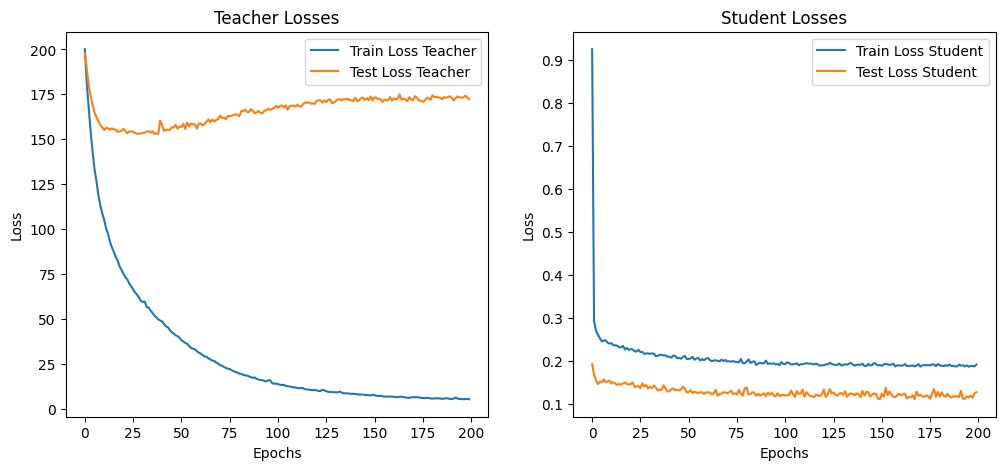

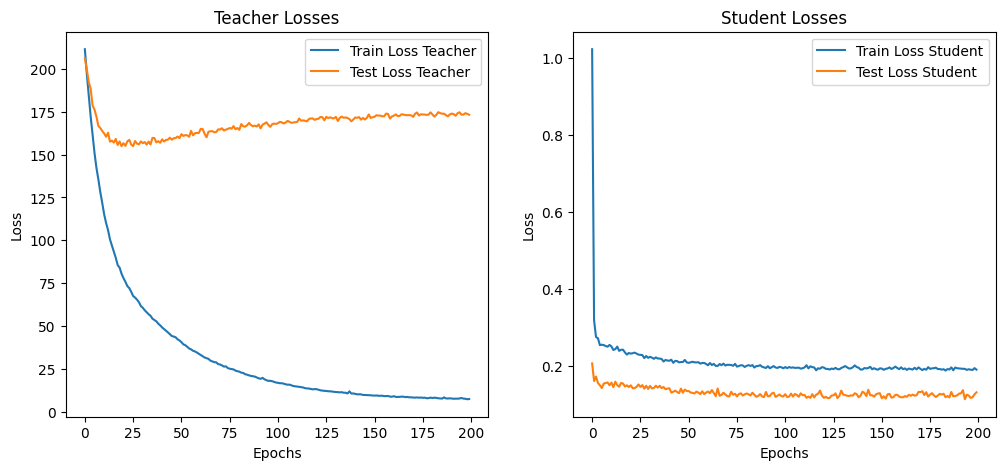

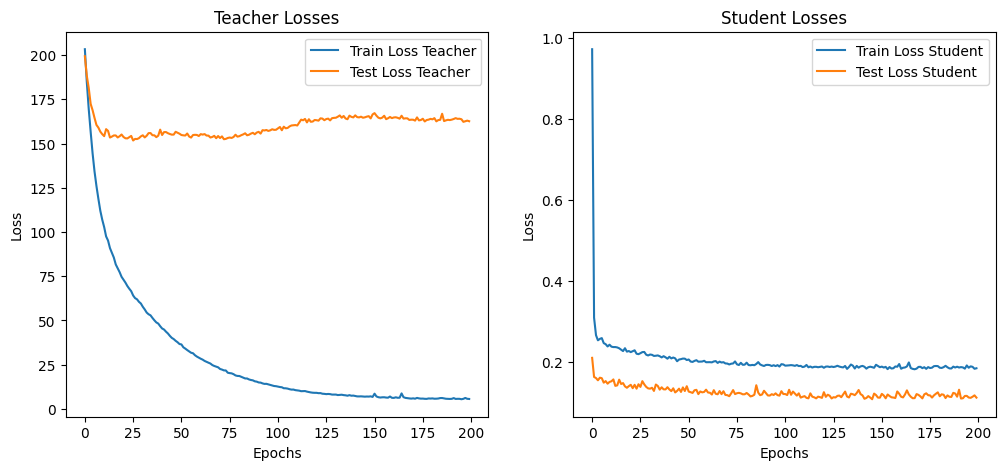

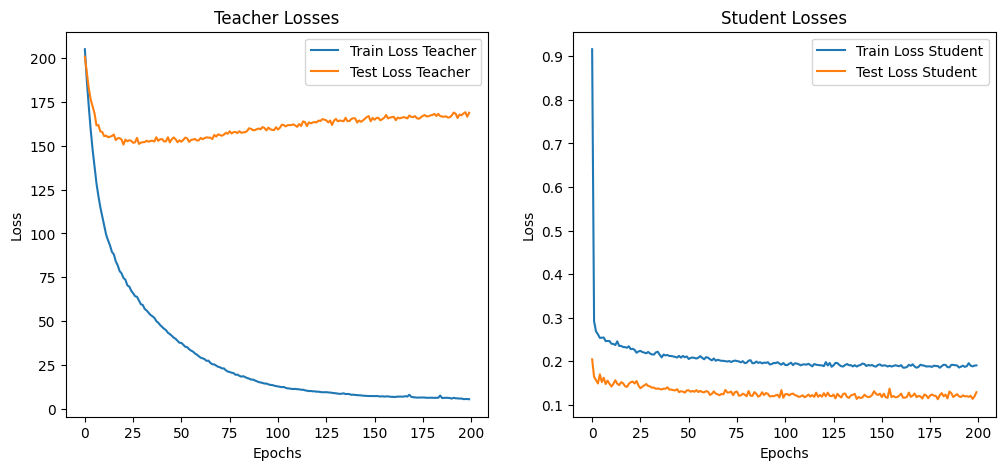

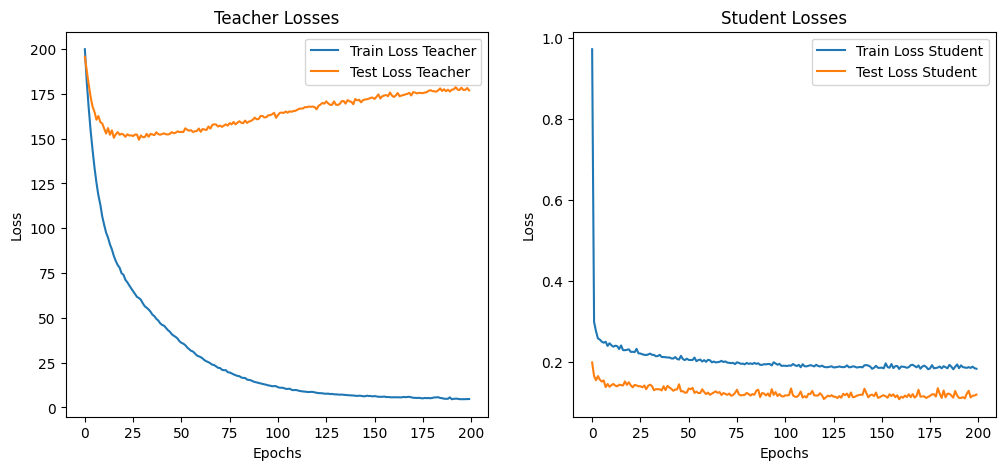

In [75]:
from model import DeepFeatureSelection
import numpy as np

top_features = {}

hidden_dim = 10

teacher_epochs = 200
teacher_regression_weight = 10
teacher_reconstruction_weight = 1
teacher_lr = 0.001

student_epochs = 200
student_lr = 0.001

train_losses_teacher_all = []
test_losses_teacher_all = []

train_losses_student_all = []
test_losses_student_all = []

for seed in range(5):
    np.random.seed(seed)
    import torch
    torch.manual_seed(seed)
    import random
    random.seed(seed)

    rrfs = DeepFeatureSelection(input_dim=X_train.shape[1], hidden_dim=hidden_dim, l1_reg=0.01)
    # 1. Train Teacher
    train_losses, test_losses = rrfs.train_teacher(X_train, y_train.values, 
                                                   X_test, y_test.values, 
                                                   epochs=teacher_epochs, 
                                                   recon_weight=teacher_reconstruction_weight, 
                                                   reg_weight=teacher_regression_weight,
                                                   lr=teacher_lr)
    train_losses_teacher_all.append(train_losses)
    test_losses_teacher_all.append(test_losses)

    # 2. Train Student
    train_losses, test_losses = rrfs.train_student(X_train, 
                                                   epochs=student_epochs, 
                                                   batch_size=32, 
                                                   lr=student_lr)
    train_losses_student_all.append(train_losses)
    test_losses_student_all.append(test_losses)

    # 3. Get Scores
    scores = rrfs.get_feature_importance()

    top = (np.argsort(scores)[::-1][:100])
    for idx in top:
        if idx in top_features:
            top_features[idx] += 1
        else:
            top_features[idx] = 1

    # plot losses
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses_teacher_all[-1], label='Train Loss Teacher')
    plt.plot(test_losses_teacher_all[-1], label='Test Loss Teacher')
    plt.title('Teacher Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()    

    plt.subplot(1, 2, 2)
    plt.plot(train_losses_student_all[-1], label='Train Loss Student')
    plt.plot(test_losses_student_all[-1], label='Test Loss Student')
    plt.title('Student Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()    

## Aggregate top features across runs
Compute the top 100 most frequently selected features from all seeds.

In [85]:
# extract top 100 features overall
import heapq

# Assume 'top_features' looks like {feature_index: count, ...}
# top_features = {0: 45, 1: 120, 2: 10, ...}

# Get top 100 (key, value) pairs based on the values
top_100_pairs = heapq.nlargest(100, top_features.items(), key=lambda item: item[1])

# Extract just the indices (keys)
top_100_indices = [pair[0] for pair in top_100_pairs]
top_100_counts = [pair[1] for pair in top_100_pairs]

print(top_100_indices)
print(top_100_counts)

[np.int64(141), np.int64(982), np.int64(195), np.int64(923), np.int64(160), np.int64(703), np.int64(532), np.int64(623), np.int64(187), np.int64(760), np.int64(465), np.int64(775), np.int64(386), np.int64(117), np.int64(893), np.int64(50), np.int64(627), np.int64(640), np.int64(960), np.int64(974), np.int64(453), np.int64(61), np.int64(8), np.int64(752), np.int64(826), np.int64(376), np.int64(822), np.int64(975), np.int64(348), np.int64(925), np.int64(77), np.int64(568), np.int64(399), np.int64(119), np.int64(1009), np.int64(389), np.int64(990), np.int64(31), np.int64(879), np.int64(802), np.int64(67), np.int64(828), np.int64(805), np.int64(632), np.int64(924), np.int64(153), np.int64(9), np.int64(912), np.int64(638), np.int64(830), np.int64(1004), np.int64(858), np.int64(614), np.int64(792), np.int64(991), np.int64(745), np.int64(710), np.int64(486), np.int64(801), np.int64(281), np.int64(780), np.int64(337), np.int64(578), np.int64(207), np.int64(45), np.int64(827), np.int64(318), np

## Helper: select top-N feature indices
Define a utility to return the indices of the top-N features.

In [86]:
# extract top 100 features overall
import heapq

# Assume 'top_features' looks like {feature_index: count, ...}
# top_features = {0: 45, 1: 120, 2: 10, ...}
def get_top_n_features(top_features, n=10):
    # Get top 100 (key, value) pairs based on the values
    top_n_pairs = heapq.nlargest(n, top_features.items(), key=lambda item: item[1])

    # Extract just the indices (keys)
    top_n_indices = [pair[0] for pair in top_n_pairs]

    return top_n_indices

## Helper: linear regression evaluation
Compute $R^2$ using a linear regression model on the top-N features.

In [87]:
def get_r2_score_regression(X_train, y_train, X_test, y_test, top_features, n=10):
    top_n_indices = get_top_n_features(top_features, n)

    # run regression with only top features
    X_test_top = X_test[:, top_n_indices]
    X_train_top = X_train[:, top_n_indices]

    from sklearn import linear_model 
    regr = linear_model.LinearRegression()
    regr.fit(X_train_top, y_train)

    r2_score = regr.score(X_test_top, y_test)
    return r2_score

## Helper: random forest evaluation
Compute $R^2$ using a random forest regressor on the top-N features.

In [88]:
def get_r2_score_random_forest(X_train, y_train, X_test, y_test, top_features, n=10):
    top_n_indices = get_top_n_features(top_features, n)

    # run regression with only top features
    X_test_top = X_test[:, top_n_indices]
    X_train_top = X_train[:, top_n_indices]

    from sklearn.ensemble import RandomForestRegressor
    regr = RandomForestRegressor(n_estimators=100, random_state=0)
    regr.fit(X_train_top, y_train)

    r2_score = regr.score(X_test_top, y_test)
    return r2_score

## Evaluate $R^2$ vs. number of top features
Run linear and random-forest regressors for different top-N sizes.

In [89]:
for n in [10, 20, 50, 100, 200, 500, 1000]:
    r2 = get_r2_score_regression(X_train, y_train, X_test, y_test, top_features, n)
    print(f"R2 score with top {n} features: {r2}")

R2 score with top 10 features: 0.1409932657575722
R2 score with top 20 features: 0.1833109975389391
R2 score with top 50 features: 0.21054220758614495
R2 score with top 100 features: 0.22263123982619282
R2 score with top 200 features: 0.21561366526325765
R2 score with top 500 features: 0.21601630714883568
R2 score with top 1000 features: 0.21601630714883568


## Evaluate random forest baseline
Repeat the evaluation using a random forest regressor.

In [43]:
for n in [10, 20, 50, 100, 200, 500, 1000]:
    r2 = get_r2_score_random_forest(X_train, y_train, X_test, y_test, top_features, n)
    print(f"R2 score with top {n} features: {r2}")

R2 score with top 10 features: 0.056277638933523
R2 score with top 20 features: 0.12386852933641312
R2 score with top 50 features: 0.19240028126329778
R2 score with top 100 features: 0.20698743540250786
R2 score with top 200 features: 0.22579473741328848
R2 score with top 500 features: 0.23063589826007924
R2 score with top 1000 features: 0.23063589826007924


## Build PyTorch data loaders
Create datasets and loaders using the top 100 features.

In [90]:
from torch.utils.data import DataLoader

top_indices = get_top_n_features(top_features, n=100)

X_train_top = X_train[:, top_indices]
X_test_top = X_test[:, top_indices]

train_loader = DataLoader(GWASDataset(X_train_top, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(GWASDataset(X_test_top, y_test), batch_size=32, shuffle=False)

## Define the DNN model
Instantiate a small neural network for regression.

In [91]:
from model import DNN

model = DNN(input_dim=X_train_top.shape[1], hidden_dims=[512, 512], output_dim=1, dropout=0.2)
print(model)

DNN(
  (network): Sequential(
    (0): Linear(in_features=100, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=512, out_features=1, bias=True)
  )
)


## Train the DNN
Optimize the model and track train/test loss per epoch.

In [92]:
from torch import nn, optim
import torch

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_losses = []
test_losses = []
 
for epoch in range(500):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        # l2 regularization
        loss = criterion(predictions, batch_y) + 0.0001 * sum(param.pow(2.0).sum() for param in model.parameters())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

    model.eval()
    test_loss = 0
    criterion = nn.MSELoss()
 
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y.view(-1, 1))
            test_loss += loss.item() * batch_X.size(0)
    
    average_test_loss = test_loss / len(test_loader.dataset)
    test_losses.append(average_test_loss)
    print(f"Test Mean Squared Error: {average_test_loss:.4f}")

Epoch 1, Loss: 20.7009
Test Mean Squared Error: 19.5437
Epoch 2, Loss: 16.9081
Test Mean Squared Error: 17.5256
Epoch 3, Loss: 14.8782
Test Mean Squared Error: 17.0273
Epoch 4, Loss: 14.1634
Test Mean Squared Error: 16.9701
Epoch 5, Loss: 13.6403
Test Mean Squared Error: 16.8243
Epoch 6, Loss: 13.2867
Test Mean Squared Error: 16.8645
Epoch 7, Loss: 12.9836
Test Mean Squared Error: 17.2264
Epoch 8, Loss: 12.6578
Test Mean Squared Error: 16.8754
Epoch 9, Loss: 12.2667
Test Mean Squared Error: 17.0024
Epoch 10, Loss: 12.0143
Test Mean Squared Error: 16.8754
Epoch 11, Loss: 11.7206
Test Mean Squared Error: 16.9268
Epoch 12, Loss: 11.3852
Test Mean Squared Error: 16.7958
Epoch 13, Loss: 10.9010
Test Mean Squared Error: 16.8830
Epoch 14, Loss: 10.6864
Test Mean Squared Error: 16.8199
Epoch 15, Loss: 10.3035
Test Mean Squared Error: 16.9019
Epoch 16, Loss: 9.8445
Test Mean Squared Error: 16.9517
Epoch 17, Loss: 9.6197
Test Mean Squared Error: 16.8172
Epoch 18, Loss: 9.4960
Test Mean Squared E

## Plot training curves
Visualize train vs. test loss over epochs.

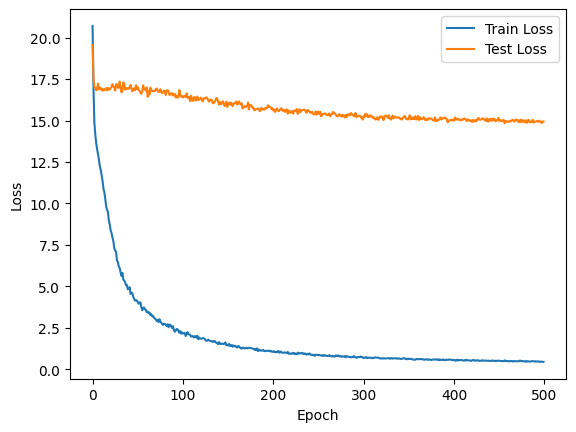

In [93]:
# plot training and test losses
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [95]:
# get the r2 score of the dnn model on test test
preds = model(torch.tensor(X_test_top, dtype=torch.float32)).detach().numpy()
from sklearn.metrics import r2_score
r2 = r2_score(y_test, preds)
print(f"R2 score of DNN model on test set: {r2}")

R2 score of DNN model on test set: 0.32590738839729183
